# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
##Cantidad de valores nulos
print(users.isna().sum())
## Proporción de valores nulos
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
##Cantidad de valores nulos
print(usage.isna().sum())
## Proporción de valores nulos
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**
¿Qué columnas tienen valores faltantes y en qué proporción?

**USERS**
- `City` cuenta con 469 nulos (11.73%)
- `Churn_date` cuenta con 3534 nulos (88.35%)

**USAGE** 
- `Date` cuenta con 50 nulos (00.12%)
- `Duration` cuenta con 22076 nulos (55.19%)
- `Lenght` cuenta con 17896 nulos (44.74%)


**Indica qué harías:** ¿imputar, eliminar, ignorar?

**USERS**
- `City` Recomiendo investigar para imputar
- `Churn_date` Recomiendo eliminar la columna ya que es innecesaria para el analisis

**USAGE**
- `Date` Recomiendo ignorar, representar la cantida minima y no afectaria el analisis
- `Duration` Recomiendo manener como (NAN); ya que los valores nulos no son datos faltantes por error, sino que representan lógicamente una correlacion con `call` de 1=1. 
- `Lenght` Recomiendo manener como (NAN); ya que los valores nulos no son datos faltantes por error, sino que representan lógicamente una correlacion con `text` de 1=1.

### 2.2 Detección de valores inválidos y sentinels

🎯 
**Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.



El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
# Resumen estadístico
print(users['user_id'].describe())
print(users['age'].describe())

count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64
count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


- La columna `user_id` se observa que los identificadores tienen un minimo de 10000 y maximo de 13999 por lo cual no se observan sentinels ni valores atipicos.
- La columna `age` se detecto un valor minimo de -999 que corresponde a un sentinel 

In [13]:
# explorar columnas numéricas de usage
print(usage['id'].describe())
print(usage['user_id'].describe())

count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64
count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64


- Las columnas `id` y `user_id`no presentan valores atipicos o sentinel 

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].value_counts()

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

- La columna `city` se observa que la ciudad de Bogota es la ciudad con mas planes siendo el basico el popular, de igual forma, se detecto que existe 2 resultados que suman 96 registros con '?'
- La columna `plan` El plan Basico es el más popular en las 4 ciudades con mayor registro de usuarios en todas (Bogota, CDMX, Medellin y GDL)

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` encontramos 2 categorias `text` con 22092 registros y `call` con 17908 registros


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- La columna `city` mostro un sentinel `?` 
- ¿Qué acción tomarías?
- Aplicaria una funcion de limpieza, reemplazandolo por un valor nulo 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se puede observar que en 2024 se obtuvo la mayor concentracion de registros con 1330, de igual forma se observa que 40 registro en el 2026 siendo una fecha erronea ya que se trabaja con registros de hasta el año 2024.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, se pueden observar 39950 registros son del 2024, no hay fechas fuera de rango y solo se tiene la presencia de 50 valores nulos

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- Se registro 1 sin transcurrir (2026)
- Como previamiente se menciono, se confirma la existencia de 50 valores nulos

¿Qué harías con ellas?
- Por lo que se recomienda transformar 40 registros con año 2026 en `reg_date` (fecha fuera de rango ya que los datos son hasta 2024) en `NAN` para no alterar analisis

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()

# Reemplazar -999 por la mediana
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [50]:
# Reemplazar ? por NaN en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False))
print(users['city'].isna().sum())


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64
565


In [22]:
# Convertir a tipo fecha (si aún no lo es)
users['reg_date'] = pd.to_datetime(users['reg_date'])

# Marcar fechas futuras como NaT
users.loc[users['reg_date'] > pd.Timestamp.today(), 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].isna().sum())
print(users['reg_date'].describe())


0
count                    4000
unique                   3961
top       2026-05-10 00:00:00
freq                       40
first     2022-01-01 00:00:00
last      2026-05-10 00:00:00
Name: reg_date, dtype: object


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
print(pd.crosstab(usage['type'], usage['duration'].isna()))

duration  False  True 
type                  
call      17908      0
text         16  22076


In [24]:
# Verificación MAR en usage (Missing At Random) para length
print(pd.crosstab(usage['type'], usage['length'].isna()))

length  False  True 
type                
call       12  17896
text    22092      0


Los nulos en duration y length son MAR: no son errores sino que son estructuralmente esperados ya que depende de otra variable observable como es `call` o `text`.
Recomiendo dejarlo como NAN 

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares

# Total de mensajes
usage["is_text"] = (usage["type"] == "text").astype(int)   
# Total de llamadas
usage["is_call"] = (usage["type"] == "call").astype(int)   

# Agrupar información por usuario
usage_agg = (
    usage
    .groupby("user_id")
    .agg({
        "is_text": "sum",
        "is_call": "sum",
        "duration": "sum"
    })
    .reset_index()
)


# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024


🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.


In [28]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
print(user_profile[columnas_numericas].describe())

               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [29]:
# Distribución porcentual del tipo de plan
print(users['plan'].value_counts(normalize=True) * 100)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 
**Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas


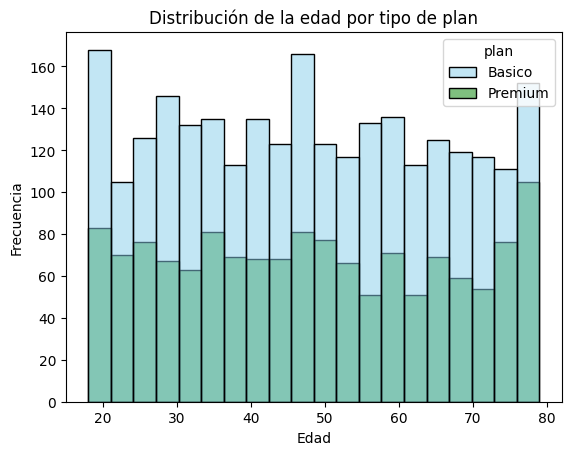

In [30]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Distribución de la edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución es simetrica por lo que la edad no parece ser un factor diferenciador en la eleccion del plan ni existe la evidencia de algun patron que explique lo contrario 

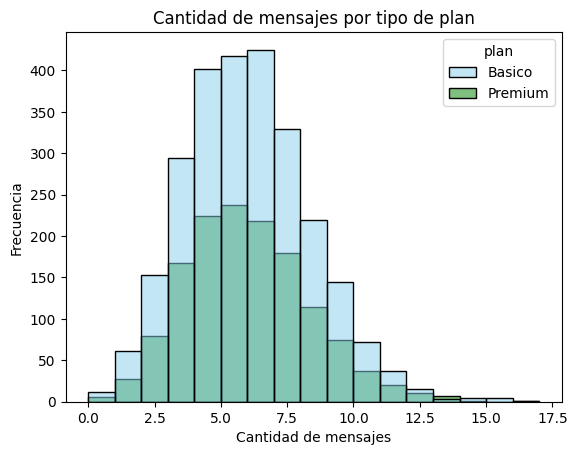

In [31]:
# Histograma para visualizar la cantidad de mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=17
)

plt.title('Cantidad de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- la distribuscion parece tener un ligero sesgo a la derecha el plan premuim parece tener una frecuencia mayor en todos los intervalos 

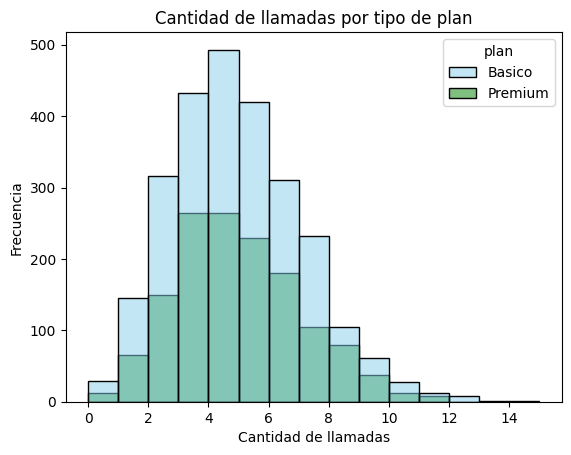

In [32]:
# Histograma para visualizar la cantidad de llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=15
)

plt.title('Cantidad de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución presenta un sesgo ligeremente a la derecha deemostrando que existe leve preferencia en el plan premium por la llamadas 

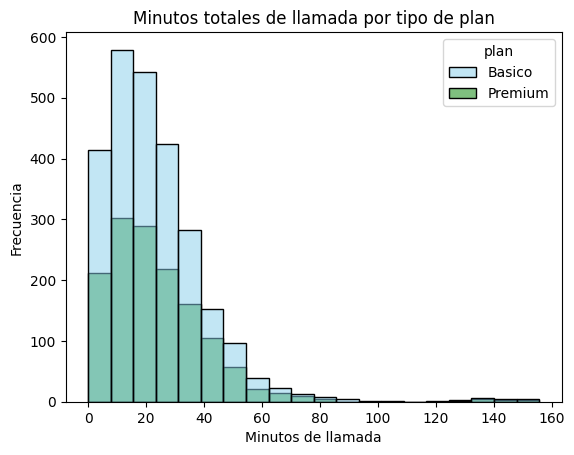

In [33]:
# Histograma para visualizar la cant_minutos_llamada
# Histograma para visualizar los minutos totales de llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Minutos totales de llamada por tipo de plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribucion presenta un claro sesgo a la derecha demostrando que se tiene mayor cantidad de llamada de menor duracion en ambos planes  

### 5.2 Identificación de Outliers

🎯 
**Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.


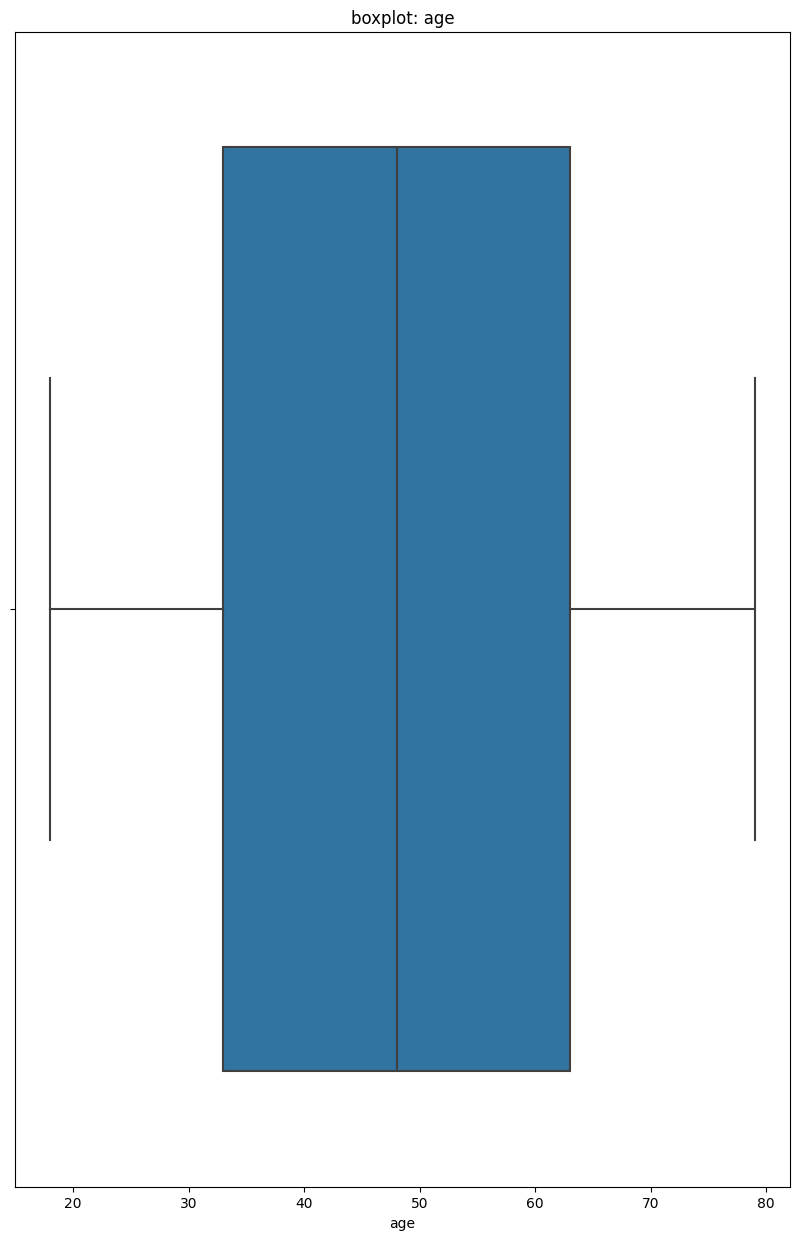

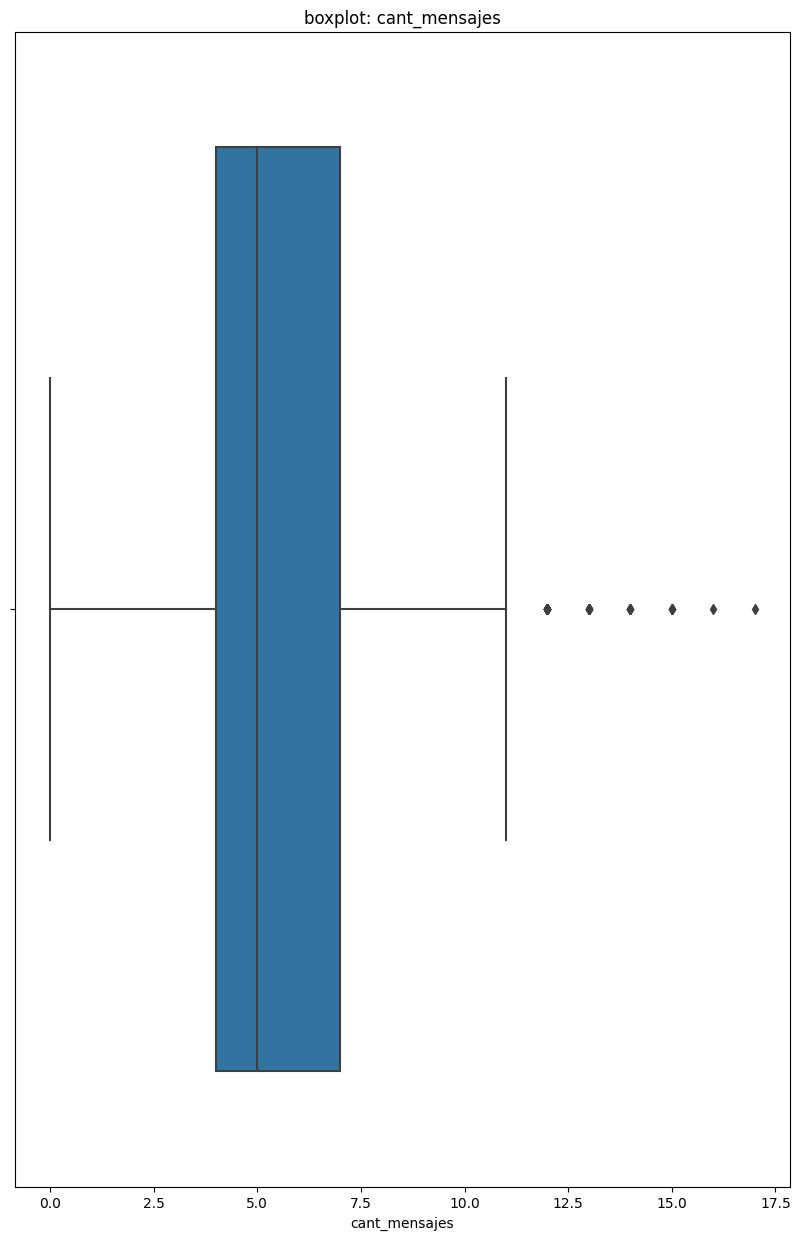

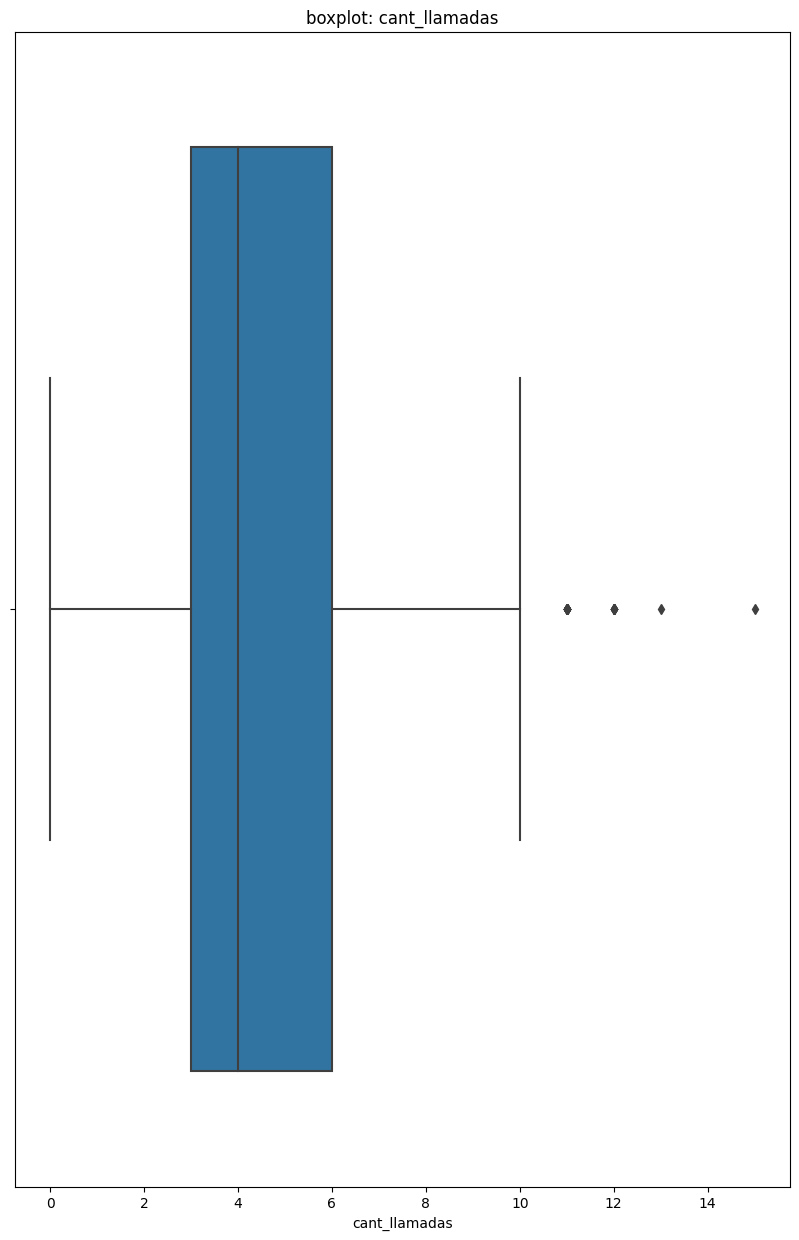

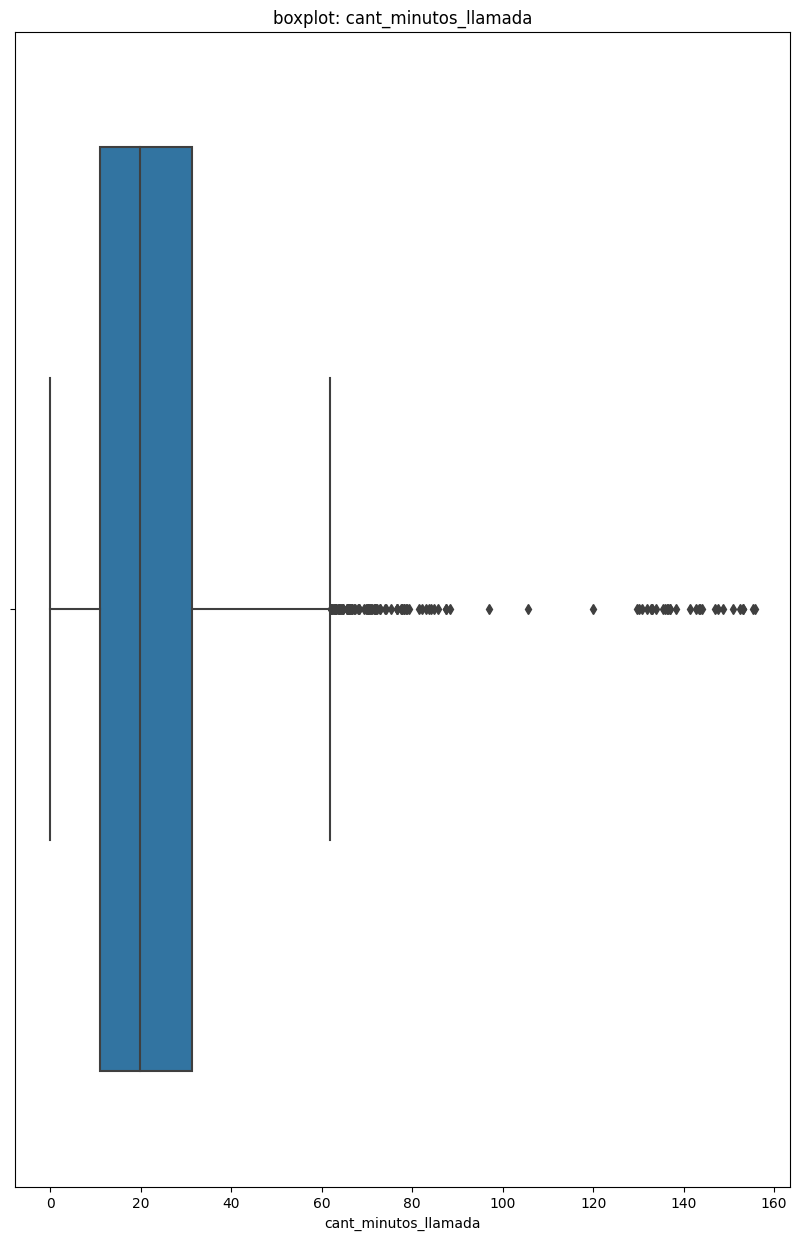

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(10,15))
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: ...(presenta o no outliers)
- cant_mensajes: Se observa 6 valores atipicos outliers 
- cant_llamadas: Se observa 4 valores atipicos outliers
- cant_minutos_llamada: Se observa un alto volumen de outliers

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col_limi in columnas_limites:
    Q1 = user_profile[col_limi].quantile(0.25)
    Q3 = user_profile[col_limi].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f'\nColumna: {col_limi}')
    print(f'Q1: {Q1:.2f}')
    print(f'Q3: {Q3:.2f}')
    print(f'IQR: {IQR:.2f}')
    print(f'Límite inferior: {limite_inferior:.2f}')
    print(f'Límite superior: {limite_superior:.2f}')


Columna: cant_mensajes
Q1: 4.00
Q3: 7.00
IQR: 3.00
Límite inferior: -0.50
Límite superior: 11.50

Columna: cant_llamadas
Q1: 3.00
Q3: 6.00
IQR: 3.00
Límite inferior: -1.50
Límite superior: 10.50

Columna: cant_minutos_llamada
Q1: 11.12
Q3: 31.41
IQR: 20.30
Límite inferior: -19.32
Límite superior: 61.86


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 

Cant_mensajes: mantener o no outliers, porqué?
-Mantener, debido a que la cantidad de mensajes es 17, siendo un valor valordo para algunos usuarios con alta actividad

Cant_llamadas: mantener o no outliers, porqué?
-Mantener, debido a que la cantidad de llamadas es 15, siendo un valor valordo para algunos usuarios con alta actividad

Cant_minutos_llamada: mantener o no outliers, porqué?
-Mantener, aunque se presenten valores maximos de 155.96 minutos el promedio es de 23.31 minutos, ademas, representa usuarios o eventualidade espontaneas pero no un error de medicion

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 
**Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos


In [37]:
# Funcion para clasificar el nivel de uso
def clasificar_uso(fila):
    if fila['cant_llamadas'] < 5 and fila ['cant_mensajes'] < 5:
        return 'Bajo uso'
        
    elif fila['cant_llamadas'] < 10 and fila ['cant_mensajes'] < 10:
        return 'Uso medio'

    else:
        return 'Alto uso'

# Crear columna grupo_uso
user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [42]:
# verificar cambios
user_profile[['cant_llamadas', 'cant_mensajes', 'grupo_uso']].head()

,cant_llamadas,cant_mensajes,grupo_uso
0,3.0,7.0,Uso medio
1,10.0,5.0,Alto uso
2,2.0,5.0,Uso medio
3,3.0,11.0,Alto uso
4,3.0,4.0,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [40]:
# Crear columna grupo_edad
def clasificar_edad(fila):

    if fila['age'] < 30:
        return 'Joven'
    elif fila ['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [44]:
# verificar cambios
user_profile[['age', 'grupo_edad']].head()

,age,grupo_edad
0,38.0,Adulto
1,53.0,Adulto
2,57.0,Adulto
3,69.0,Adulto Mayor
4,63.0,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

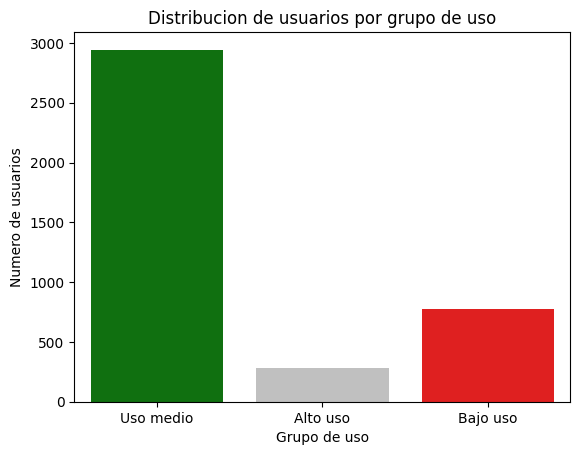

In [49]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile,
             x='grupo_uso',
             palette=['green', 'silver', 'red'])

plt.xlabel("Grupo de uso")
plt.ylabel("Numero de usuarios")
plt.title("Distribucion de usuarios por grupo de uso")
plt.show()

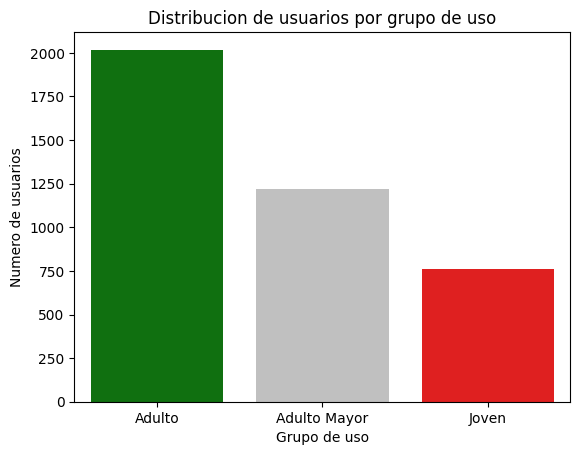

In [48]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile,
             x='grupo_edad',
             palette=['green', 'silver', 'red'])

plt.xlabel("Grupo de uso")
plt.ylabel("Numero de usuarios")
plt.title("Distribucion de usuarios por grupo de uso")
plt.show()

In [55]:
# Cantidad de usuarios por grupo de edad, plan y grupo de uso
Cantidad_edad_plan_uso = (
    user_profile
    .groupby(['grupo_edad', 'plan', 'grupo_uso'])
    .size()
    .reset_index(name='cantidad')
)

print(Cantidad_edad_plan_uso)

      grupo_edad     plan  grupo_uso  cantidad
0         Adulto   Basico   Alto uso       108
1         Adulto   Basico   Bajo uso       240
2         Adulto   Basico  Uso medio       977
3         Adulto  Premium   Alto uso        46
4         Adulto  Premium   Bajo uso       124
5         Adulto  Premium  Uso medio       523
6   Adulto Mayor   Basico   Alto uso        43
7   Adulto Mayor   Basico   Bajo uso       173
8   Adulto Mayor   Basico  Uso medio       568
9   Adulto Mayor  Premium   Alto uso        31
10  Adulto Mayor  Premium   Bajo uso        84
11  Adulto Mayor  Premium  Uso medio       323
12         Joven   Basico   Alto uso        35
13         Joven   Basico   Bajo uso        99
14         Joven   Basico  Uso medio       352
15         Joven  Premium   Alto uso        16
16         Joven  Premium   Bajo uso        58
17         Joven  Premium  Uso medio       200


In [56]:
# Porcentaje de grupo de uso según grupo de edad y plan
grupo_edad_uso = pd.crosstab(
    [user_profile['grupo_edad'], user_profile['plan']],
    user_profile['grupo_uso'],
    normalize='index'
) * 100

print(grupo_edad_uso.round(2))

grupo_uso             Alto uso  Bajo uso  Uso medio
grupo_edad   plan                                  
Adulto       Basico       8.15     18.11      73.74
             Premium      6.64     17.89      75.47
Adulto Mayor Basico       5.48     22.07      72.45
             Premium      7.08     19.18      73.74
Joven        Basico       7.20     20.37      72.43
             Premium      5.84     21.17      72.99


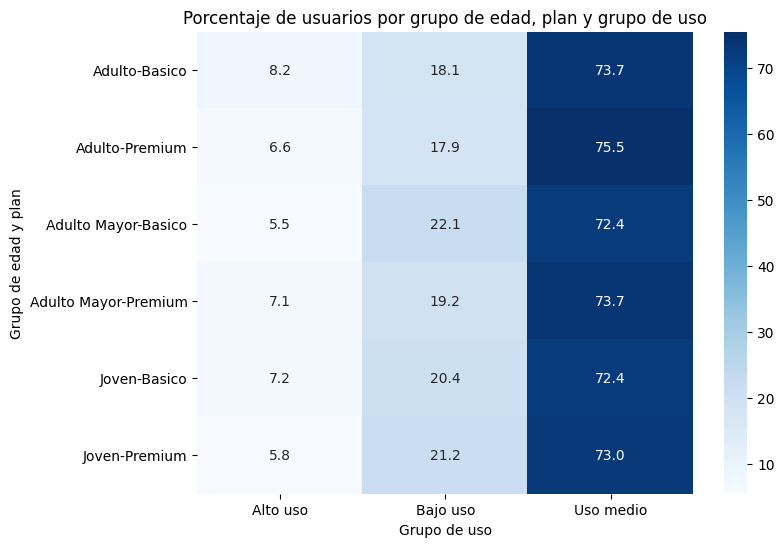

In [58]:
plt.figure(figsize=(8,6))

sns.heatmap(
    grupo_edad_uso,
    annot=True,
    fmt='.1f',
    cmap='Blues'
)

plt.title('Porcentaje de usuarios por grupo de edad, plan y grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Grupo de edad y plan')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
-¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

-¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  

-¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  

-¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

-¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

-Se observaron 7 problemas originales 4 en dataset `USERS` columnas `city` (nulos 11.7% + sentinel "?"), `churn_date` (nulos 88.35), `age`(sentinel -999) y `reg_date` (40 registros de fechas del 2026); 3 en dataset `USAGE` columnas `date`(50 nulos (0.12%), `duration`(	Nulos MAR (55.19%) y `length`(Nulos MAR (44.74%), de igual forma surgio en el analisis outliers naturales que "Representa usuarios o eventualidades espontáneas pero no un error de medición"

🔍 **Segmentos por Edad**

-Se identificó que los cerca del 50% de los usuarios registrados son `adultos` y la mayoría tienen un `uso medio`, pero no existe algún patrón especifico en relación con la edad y el uso o tipo de contratación de plan (básico o premium)

📊 **Segmentos por Nivel de Uso**

-El segmento `adultos con plan basico y de uso medio` ya que su cantidad de registros es de 977 que representa una estrategia de fidelizacion y el inicio de incentivar la migracion al plan `premium`  
-Se encontraron outliers en 3 variables: `cant_mensajes`, `cant_llamadas` y `cant_minutos_llamada. Estos no representan errores de medición sino eventualidades espontaneass. Para el negocio, implican una oportunidad ya que representa una oportunidad ya sea para incrementar a un plan más caro que premium y cobrar un uso exesivo al contratado

💡 **Recomendaciones**

-Recomiendo crear un plan mayor para cubrir la demanda de `Alto uso` y `Usuarios con outliers`en plan `Premium` e incentivar a los planes `Basicos` de `Alto uso` integrarse al nuevo plan o mejorar al premium  
-Incentiva la migracion de los `Adultos de plan basico con uso medio` a `Premium` con descuentos temporales o facilidades de pago como anualidades

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`